# Pricing the St. Petersburg Paradox

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import pandas as pd
import math
from collections import Counter
%matplotlib inline

### 1 - Simulations

In [170]:
def simulate_game(cumulative_prize: int, current_prize: int, max_prize: int = math.inf) -> int:
  """
  Arguments:
  cumulative_prize -- the total prize money accumulated to this point
  current_prize -- prize to be awarded if heads is tossed at the current timestep
  max_prize -- max prize to simulate a game with a predefined prize threshold

  Returns:
  cumulative_prize -- the total prize money accumulated
  """
  if max_prize < cumulative_prize:
    return max_prize

  # we assume that the coin toss returns tails when random number <= 0.5
  if random.random() <= 0.5:
    return cumulative_prize

  # at this point, we know that the coin toss was a heads
  cumulative_prize += current_prize
  next_prize = 2 * current_prize

  return simulate_game(cumulative_prize, next_prize, max_prize)

def repeat_simulation(num_games: int, max_prize: int = math.inf) -> list:
  """
  Arguments:
  num_games -- number of simulations to conduct
  eg. repeat_simulations(10) will simulate playing 10 games.
  max_prize -- simulate games with a predefined maximum prize threshold

  Returns:
  results -- results for the simulations conducted
  """
  results = list()

  for num in range(0, num_games):
    results.append(simulate_game(0, 2, max_prize))

  return results

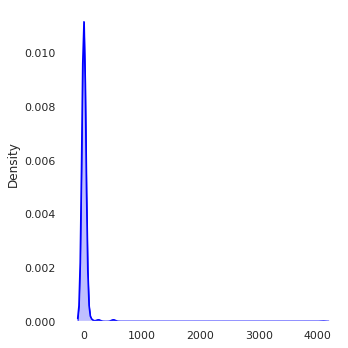

In [179]:
# simulate playing a 1000 games and repeat this process once.
simulation_results = repeat_simulation(1000)

# plot the distribution of winnings
sns.color_palette('Set2')
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
ax = sns.displot(simulation_results, kind = 'kde', color = 'blue')
ax = sns.kdeplot(simulation_results, color = 'blue', fill = True)

It is not surprising to see that the simulations return a fat-tailed distribution of payoffs given the rules of the game which contribute to extreme variations in outcomes. The distribution exhibits positive skewness and high kurtosis indicative of outliers.

In [180]:
df = pd.DataFrame()
counts = dict(Counter(simulation_results))

prize_money = list(counts.keys()) 
prize_counts = list(counts.values())
total_count = np.sum(prize_counts)
probabilities = (prize_counts / total_count)
expected_values = prize_money * probabilities

temp = pd.DataFrame({
    'prize_money': prize_money, 
    'probability': probabilities,
    'expected_value': expected_values
})

df = df.append(temp)

In [181]:
df = df.sort_values(by = 'probability', ascending = False)
df

,prize_money,probability,expected_value
0,0,0.471,0.000
1,2,0.266,0.532
2,6,0.131,0.786
4,14,0.064,0.896
3,30,0.037,1.110
6,62,0.014,0.868
8,126,0.006,0.756
5,254,0.005,1.270
7,510,0.005,2.550
9,4094,0.001,4.094


### 3 - Preliminary thoughts on pricing the game

The results of the simulation shows that the payoffs per game follow a positive-skewed distribution with high kurtosis and events with extremely low probabilites contribute quite significantly to the total expected value. The St. Petersburg paradox reminds be of the black swan theory by Taleb. A black swan is basically any event with a small probability but with immense positive or negative consequences. 

- In this case, the players of the game are subject to positive black swans as their winnings in a game are essentially uncapped as long as they keep tossing heads, however, the probability of winning large amounts is quite low.
- The casino on the other hand is subject to negative black swans as in theory there is a non-zero probability that there exists a player who walks into the casino and is able to toss enough heads in a row to put the casino out of business. This also raises the question of whether a casino would be able to fully compensate the prize won by a customer.
- Another point to consider is that the probability of an event and the history of all events will tell us little about when a particular event will happen if each event is independent of the other. In the context of this game, consider a large number $X$ such that the payoff for tossing $X$ consecutive heads puts the casino out of business. If the probability of tossing $X$ consecutive heads is $P(X\;heads)$ then $P(X\;heads)$ and the history of observed games will do little to inform us about when $X$ consecutive heads will be tossed. 

A casino faces genuine risk of going out of business if it permits this game on its premises and so it might be unadvisable to do so. However, I tried to play with the idea of what happens if a casino decides to allow this game on its premise:
- The uncertainty in the timing and size of prizes implies that from a casino's point of view there must be at the bare minimum a very large premium which should be reflected in the price that a customer has to pay in order to partake in this game and compensate the casino for taking on an inordinate amount of risk. In actuality, no premium is sufficient to compensate the casino's risk given the non-zero probability of a player's payoff going to infinity.
- Putting myself in the shoes of a player, I find myself reluctant to pay a high price to play this game. This stems from the fact that there is a low probability of large payoffs based on the game's rules. This is confirmed by our previous simulations which show that a large portion of the expected payoffs are accounted for by highly improbable events. Given that there's a small chance that I play enough games to significantly increase the odds of getting a large payoff, paying a high price for the game wouldn't make sense since it is unlikely that I would recoup my capital.
- We can also consider a player who takes into account the asymmetric payoffs and would like to improve their chances of being exposed to large wins by repeatedly playing the game. The notion here would be that the large win would more than make up for all the fees paid to the casino for playing the previous games plus compensate the player for other opportunity costs endured during the course of play. However, the payoffs could be low for a lot longer than a player can stay solvent. But, we can't discount the notion that such a player may exist and this course of action may be the most rational way to act for a player with a near infinite bankroll to buy into games given that the payoff is uncapped.

## tl;dr
- A casino will not be able to price the game in a way that the price internalizes the blow up risk it has to take on.
- In the unlikely scenario that a casino ascertains a price for playing the game, this price would not be agreeable to the players as it would be much higher than the intuitive price that a player would place on it.
- For a player seeking asymmetric payoffs by repeatedly playing the game, the payoffs could be low long after the player is insolvent given the fat-tailed distribution of payoffs and the uncertainty of when a large reward is won in the game. However, there is a non-zero probability that such a player exists.

### 4 - Adding a maximum prize threshold to the game.

If a casino insists on keeping this game on its premises one option that the casino has is to cap the winnings. For example, we can set a maximum prize to be won to say $\$1000$. This outcome is infact only possible if a player is able to get $log2(1000) \approx 10$ consecutive heads which gives it a probability of $\frac{1}{2}^{10} \approx 0.00098$.

Next, we can run simulations for this variation of the game where the maximum prize threshold is set to $\$1000$.

In [189]:
MAX_PRIZE = 1000
simulation_results = repeat_simulation(1000000, MAX_PRIZE)

df = pd.DataFrame()

counts = dict(Counter(simulation_results))
prize_money = list(counts.keys()) 
prize_counts = list(counts.values())
total_count = np.sum(prize_counts)
probabilities = (prize_counts / total_count)
expected_values = prize_money * probabilities

temp = pd.DataFrame({
    'prize_money': prize_money, 
    'probability': probabilities,
    'expected_value': expected_values
})

df = df.append(temp)

In [190]:
df = df.sort_values(by = 'probability', ascending = False)
df

,prize_money,probability,expected_value
1,0,0.500205,0.000000
0,2,0.249551,0.499102
2,6,0.125265,0.751590
3,14,0.062497,0.874958
5,30,0.031098,0.932940
4,62,0.015599,0.967138
9,126,0.007804,0.983304
8,254,0.003949,1.003046
7,510,0.002017,1.028670
6,1000,0.002015,2.015000


In [191]:
expected_value = np.sum(df['expected_value'])
print(f'The expected value for a game played with ${MAX_PRIZE} as the max prize is {expected_value}')

# probability that a customer wins more than the price to play the game
profit_probability = np.sum(df[df['prize_money'] >= expected_value]['probability'])
print(f'The probability of a customer profiting is {profit_probability}')

The expected value for a game played with $1000 as the max prize is 9.055748000000001
The probability of a customer profiting is 0.124979


For this variation of the St. Petersburg Paradox game with a maximum payoff threshold, the expected value obtained by running our simulation should adequately compensate a casino and allow it to breakeven over a sufficiently long stretch of time. However, it still does not seem likely that customers of the casino would find the price calculated using this method agreeable given that a large contribution to the expected value and subsequently the price is from events with overwhelmingly low probabilities and a rough calculation shows that customers have only a $0.125$ probability of actually recouping their money or turning a profit. These odds are much lower than most other casino games and probably put this game at the top of the list of games with the worst odds from a player's perspective (ref: https://www.liveabout.com/get-an-edge-at-the-casino-by-knowing-which-games-have-the-best-odds-4582276).